### Übung 6 Clustering

#### Aufgabe 1: Fuzzy Clustering (5)

Verwenden Sie den Iris Datensatz.

__a)__ Verwenden Sie  das Fuzzy Clustering. Lassen Sie sich die Daten einmal so anzeigen, dass die beste Zugehörigkeit (argmax) angezeigt wird, und einmal, dass für jedes Cluster, die Zugehörigkeit farblich dargestellt wird (3 Plots, einen je Cluster) 

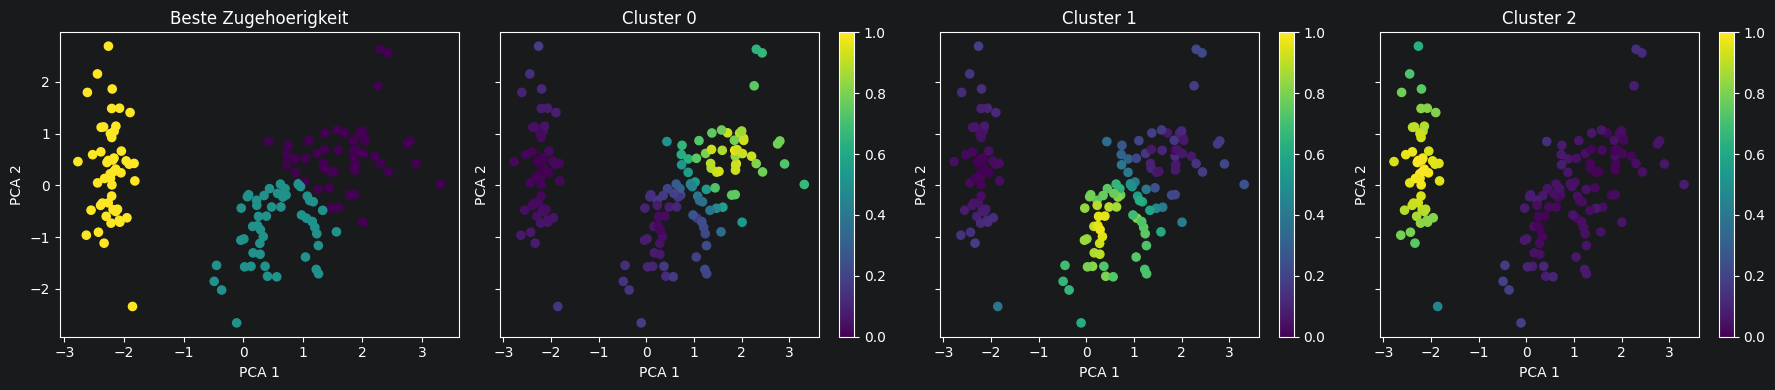

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


iris = load_iris()
X = iris.data

X_scaled = StandardScaler().fit_transform(X)
PCA = PCA(n_components=2, random_state=42).fit_transform(X_scaled)


# Fuzzy C-Means mit 3 Clustern.
# skfuzzy erwartet die Daten transponiert: Merkmale x Datenpunkte.
centers, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_scaled.T,
    c=3,
    m=2,
    error=0.005,
    maxiter=1000,
    seed=42,
)

labels = np.argmax(u, axis=0)


fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)

axes[0].scatter(PCA[:, 0], PCA[:, 1], c=labels, cmap="viridis", s=35)
axes[0].set_title("Beste Zugehoerigkeit")

for cluster in range(3):
    plot = axes[cluster + 1].scatter(
        PCA[:, 0],
        PCA[:, 1],
        c=u[cluster],
        cmap="viridis",
        s=35,
        vmin=0,
        vmax=1,
    )
    axes[cluster + 1].set_title(f"Cluster {cluster}")
    plt.colorbar(plot, ax=axes[cluster + 1])

for ax in axes:
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

plt.tight_layout()
plt.show()

__b)__ Verwenden Sie verschieden $m$ Parameter (z.B. 0.5,1.0001,2,3,5,10,100,1000) und visualisieren Sie wieder nach Clusterzugehörigkeit.

C:\Users\toyel\AppData\Roaming\Python\Python313\site-packages\skfuzzy\cluster\_cmeans.py:27: RuntimeWarning: invalid value encountered in divide
  cntr = um.dot(data) / np.atleast_2d(um.sum(axis=1)).T


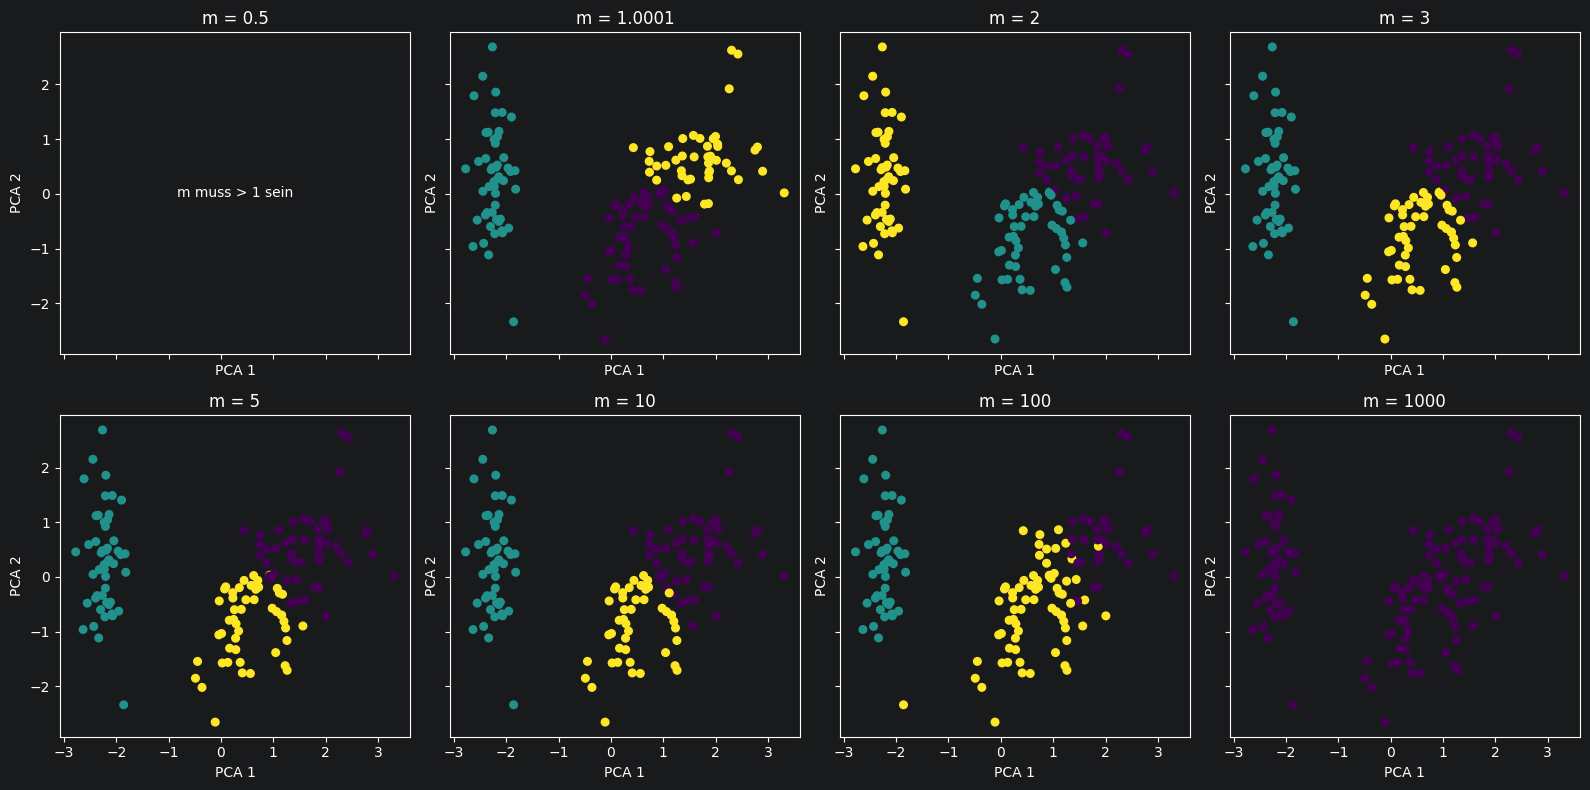

In [2]:
m_werte = [0.5, 1.0001, 2, 3, 5, 10, 100, 1000]

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)

for ax, m in zip(axes.ravel(), m_werte):
    if m <= 1:
        ax.text(
            0.5,
            0.5,
            "m muss > 1 sein",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_title(f"m = {m}")
    else:
        centers, u, _, _, _, _, _ = fuzz.cluster.cmeans(
            X_scaled.T,
            c=3,
            m=m,
            error=0.005,
            maxiter=1000,
            seed=42,
        )
        labels = np.argmax(u, axis=0)

        ax.scatter(PCA[:, 0], PCA[:, 1], c=labels, cmap="viridis", s=30)
        ax.set_title(f"m = {m}")

    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

plt.tight_layout()
plt.show()

#### Aufgabe 2:  DBSCAN (10)

Verwenden Sie wieder den Irisdatensatz


__a)__ Clustern Sie die skalierten Daten (nicht PCA transformiert) nun mit DBSCAN, verwenden Sie unterschiedliche Werte für _epsilon_ und _minPts_ (mind. 9 unterschiedliche Kombinationen). Visualisieren Sie die Cluster dimensionsreduziert auf zwei Dimensionen. 

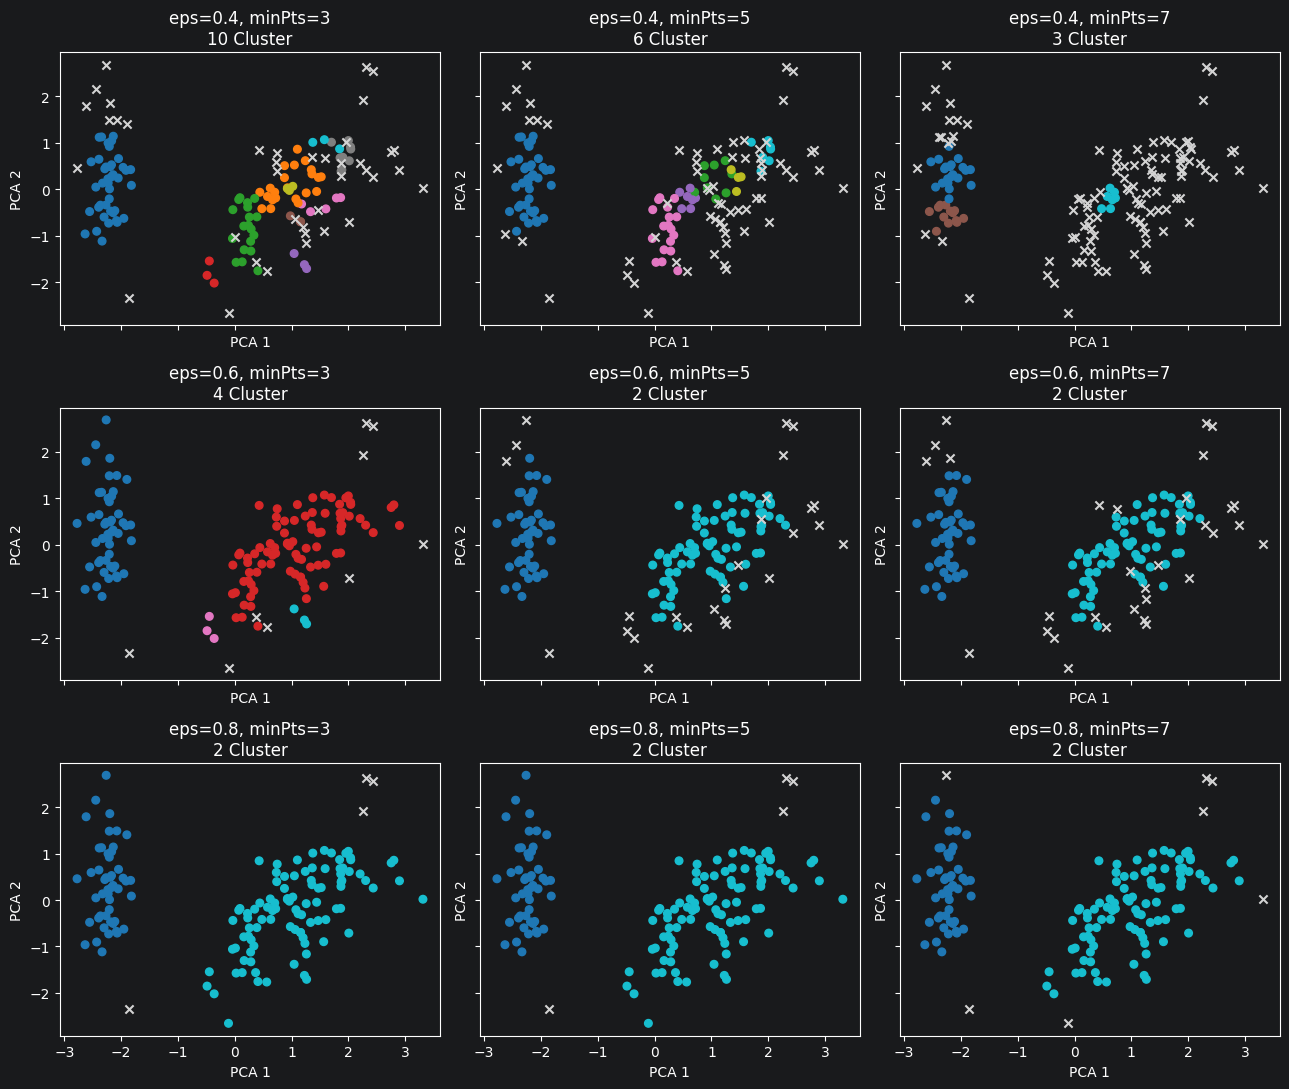

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN


iris = load_iris()
X_scaled = StandardScaler().fit_transform(iris.data)
PCA = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

parameter = [
    (0.4, 3), (0.4, 5), (0.4, 7),
    (0.6, 3), (0.6, 5), (0.6, 7),
    (0.8, 3), (0.8, 5), (0.8, 7),
]

fig, axes = plt.subplots(3, 3, figsize=(13, 11), sharex=True, sharey=True)

for ax, (eps, min_pts) in zip(axes.ravel(), parameter):
    labels = DBSCAN(eps=eps, min_samples=min_pts).fit_predict(X_scaled)
    noise = labels == -1
    anzahl_cluster = max(labels) + 1

    ax.scatter(PCA[~noise, 0], PCA[~noise, 1], c=labels[~noise], cmap="tab10", s=30)
    ax.scatter(PCA[noise, 0], PCA[noise, 1], c="lightgray", marker="x", s=35)
    ax.set_title(f"eps={eps}, minPts={min_pts}\n{anzahl_cluster} Cluster")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

plt.tight_layout()
plt.show()

__b)__ Erstellen Sie einen Plot über unterschiedliche _minPts_ und _epsilon_ Werte mit Hilfe von _k_ Nächsten-Nachbarn. Dabei soll für jedes _k_ ($ \in \{2,3,5,7,9\}$) ein Plot entstehen aus dem der jeweilige beste _epsilon_ Wert ermittelt wird. Im Anschluss sollen noch einmal für die besten Kombinationen der DBSCAN laufen gelassen werden und der Plot der vorherigen Aufgabe je Kombination erstellt werden.

__Hinweis:__ Eine möglichst gute Kombination finden Sie an dem Punkt der Kurve, an dem eine möglichst starke Krümmung besteht. 

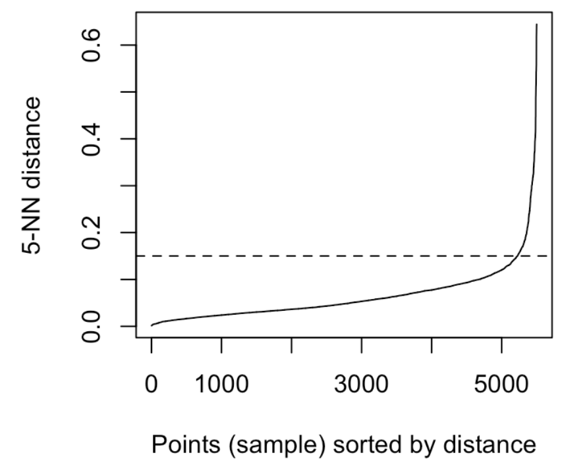

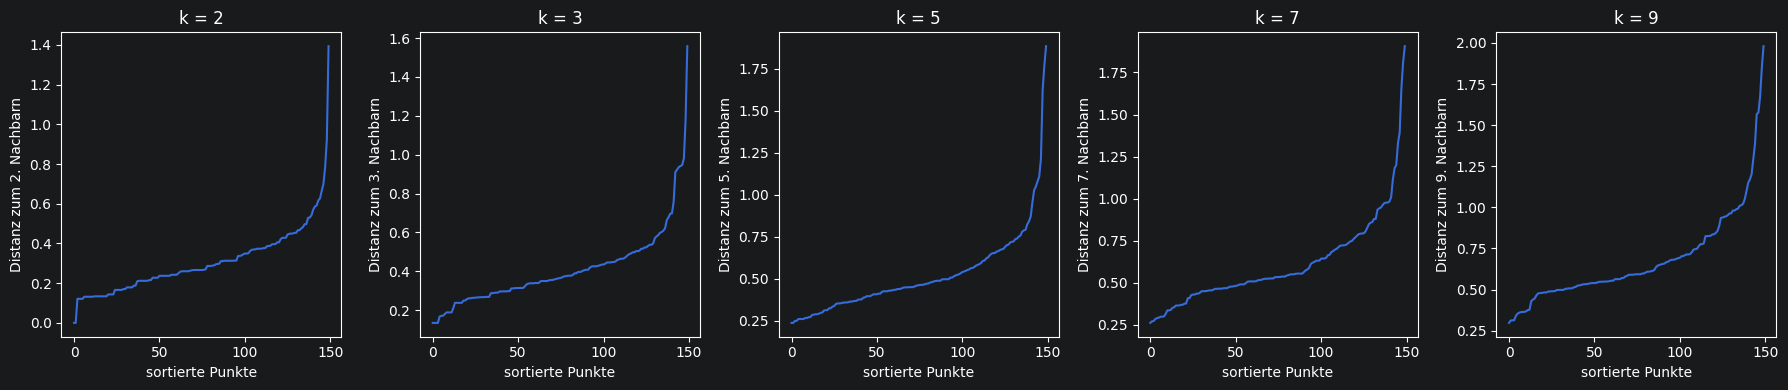

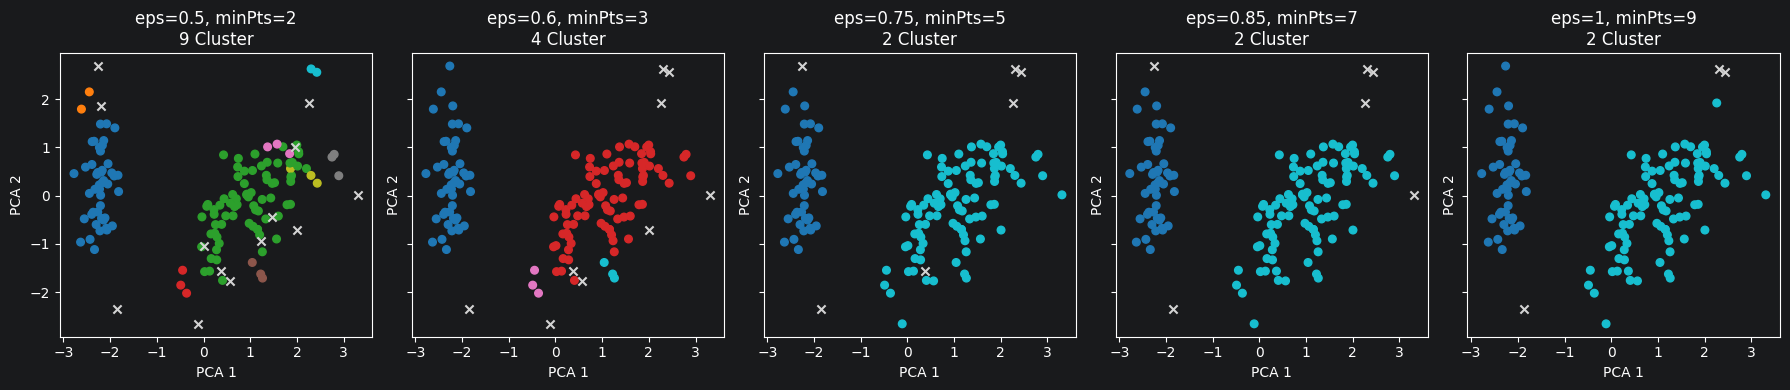

In [8]:
from sklearn.neighbors import NearestNeighbors


k_werte = [2, 3, 5, 7, 9]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, k in zip(axes, k_werte):
    nearest_neighbors = NearestNeighbors(n_neighbors=k)
    distances, _ = nearest_neighbors.fit(X_scaled).kneighbors(X_scaled)
    k_distances = np.sort(distances[:, -1])

    ax.plot(k_distances)
    ax.set_title(f"k = {k}")
    ax.set_xlabel("sortierte Punkte")
    ax.set_ylabel(f"Distanz zum {k}. Nachbarn")

plt.tight_layout()
plt.show()


# Ungefäre werte abgelesen
beste_kombinationen = [
    (0.5, 2),
    (0.6, 3),
    (0.75, 5),
    (0.85, 7),
    (1, 9),
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharex=True, sharey=True)

for ax, (eps, min_pts) in zip(axes, beste_kombinationen):
    labels = DBSCAN(eps=eps, min_samples=min_pts).fit_predict(X_scaled)
    noise = labels == -1
    anzahl_cluster = max(labels) + 1

    ax.scatter(PCA[~noise, 0], PCA[~noise, 1], c=labels[~noise], cmap="tab10", s=30)
    ax.scatter(PCA[noise, 0], PCA[noise, 1], c="lightgray", marker="x", s=35)
    ax.set_title(f"eps={eps}, minPts={min_pts}\n{anzahl_cluster} Cluster")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

plt.tight_layout()
plt.show()

#### Aufgaben 3: Vergleich der Algorithmen (10)

Verwenden Sie k-means, DBSCAN, Hierarchisches Clustern und EM-Algorithmus und clustern Sie die unteren Datensätze möglichst gut. Visualisieren Sie Ihr jeweils bestes Ergebnis (je Datensatz und je Algorithmus)

* X, y = make_moons(n_samples=200, noise=0.05, random_state=42)
* X, y = make_circles(n_samples=400, factor=.3, noise=.05)
* X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
* Mikey Mouse

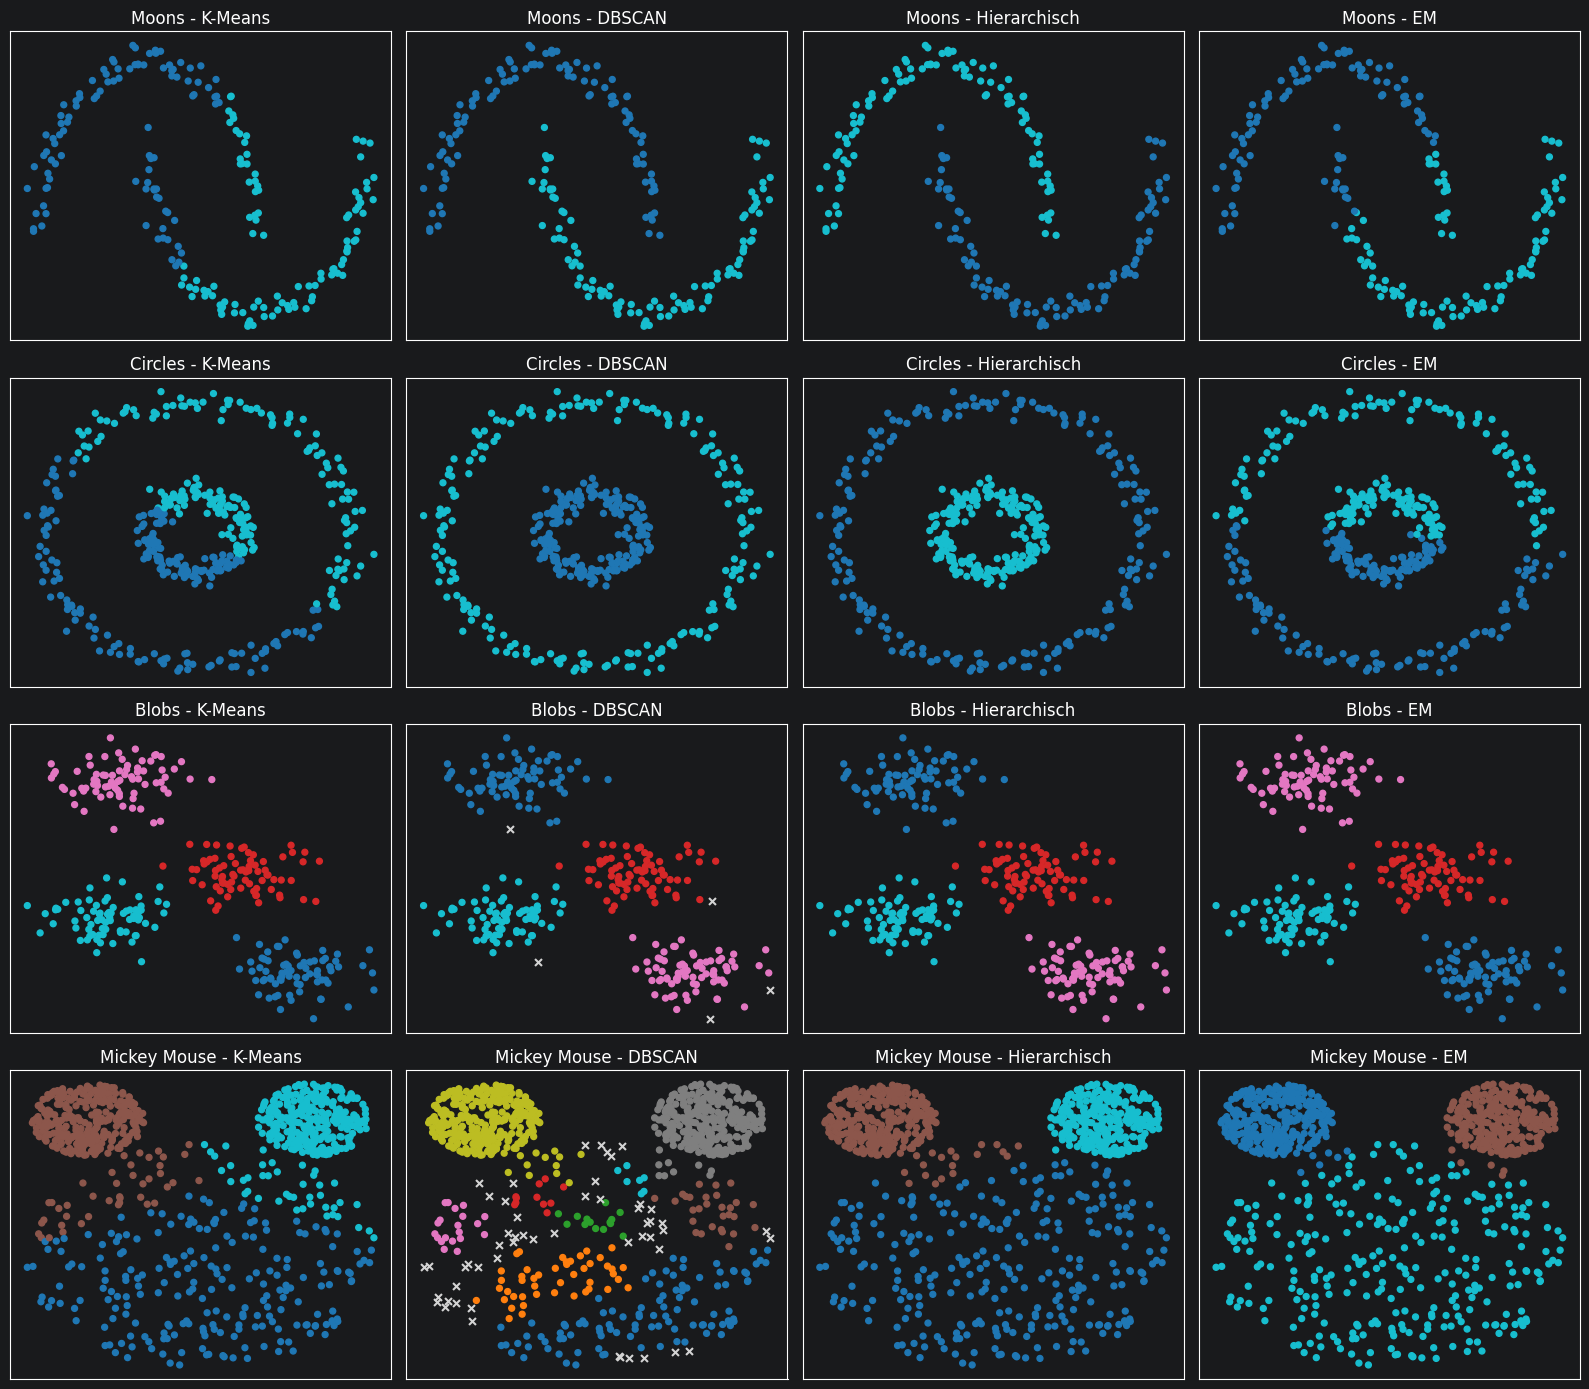

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture


X_moons, y = make_moons(n_samples=200, noise=0.05, random_state=42)
X_circles, y = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=42)
X_blobs, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
X_mickey = pd.read_csv("mickeythemouse.csv")[["x", "y"]].to_numpy()

datensaetze = [
    ("Moons", X_moons, 2, 0.25, 5, "single"),
    ("Circles", X_circles, 2, 0.3, 5, "single"),
    ("Blobs", X_blobs, 4, 0.65, 5, "ward"),
    ("Mickey Mouse", X_mickey, 3, 0.445, 11, "ward"),
]

fig, axes = plt.subplots(4, 4, figsize=(16, 14))

for zeile, (name, X, n_cluster, eps, min_pts, linkage) in enumerate(datensaetze):
    labels_kmeans = KMeans(n_clusters=n_cluster, random_state=42, n_init=10).fit_predict(X)
    labels_dbscan = DBSCAN(eps=eps, min_samples=min_pts).fit_predict(X)
    labels_hier = AgglomerativeClustering(n_clusters=n_cluster, linkage=linkage).fit_predict(X)
    labels_em = GaussianMixture(n_components=n_cluster, random_state=42).fit(X).predict(X)

    ergebnisse = [
        ("K-Means", labels_kmeans),
        ("DBSCAN", labels_dbscan),
        ("Hierarchisch", labels_hier),
        ("EM", labels_em),
    ]

    for spalte, (algorithmus, labels) in enumerate(ergebnisse):
        ax = axes[zeile, spalte]
        noise = labels == -1

        ax.scatter(X[~noise, 0], X[~noise, 1], c=labels[~noise], cmap="tab10", s=18)
        ax.scatter(X[noise, 0], X[noise, 1], c="lightgray", marker="x", s=25)
        ax.set_title(f"{name} - {algorithmus}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

### Zusatzaufgabe (5)

Picken Sie sich einen Datensatz heraus. Verändern Sie die Anzahl der Punkte systematisch und messen Sie die Laufzeit je Algorithmus und Punktanzahl. Visualisieren Sie Ihre Ergebnisse in geeigneter Art und Weise.

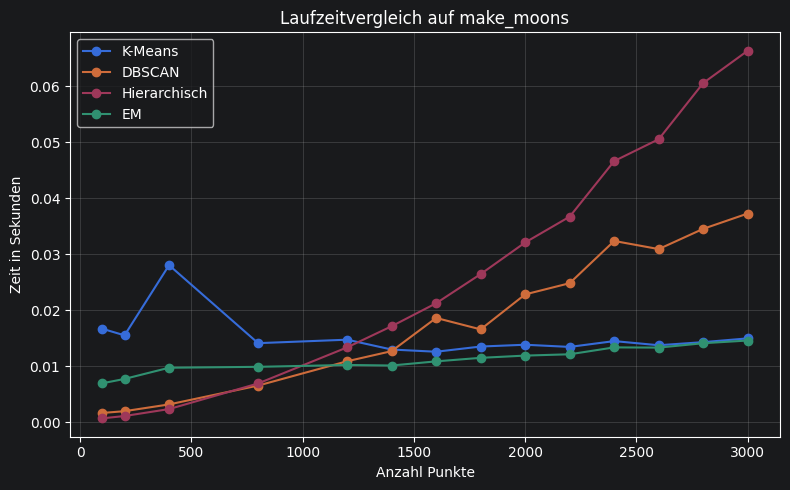

In [44]:
import time
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture


punktzahlen = [100, 200, 400, 800, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000]

zeiten_kmeans = []
zeiten_dbscan = []
zeiten_hier = []
zeiten_em = []

for n in punktzahlen:
    X, y = make_moons(n_samples=n, noise=0.05, random_state=42)

    start = time.perf_counter()
    KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X)
    zeiten_kmeans.append(time.perf_counter() - start)

    start = time.perf_counter()
    DBSCAN(eps=0.25, min_samples=5).fit_predict(X)
    zeiten_dbscan.append(time.perf_counter() - start)

    start = time.perf_counter()
    AgglomerativeClustering(n_clusters=2, linkage="single").fit_predict(X)
    zeiten_hier.append(time.perf_counter() - start)

    start = time.perf_counter()
    em = GaussianMixture(n_components=2, random_state=42).fit(X)
    em.predict(X)
    zeiten_em.append(time.perf_counter() - start)


plt.figure(figsize=(8, 5))
plt.plot(punktzahlen, zeiten_kmeans, marker="o", label="K-Means")
plt.plot(punktzahlen, zeiten_dbscan, marker="o", label="DBSCAN")
plt.plot(punktzahlen, zeiten_hier, marker="o", label="Hierarchisch")
plt.plot(punktzahlen, zeiten_em, marker="o", label="EM")

plt.title("Laufzeitvergleich auf make_moons")
plt.xlabel("Anzahl Punkte")
plt.ylabel("Zeit in Sekunden")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()